# Section 6 &middot; Meta-Labeling with CatBoost

*The Honest Edge.*

This is the section the whole course has been building toward. We have a real rule that
proposes trades (Connors RSI-2, Section 3), an honest answer key for each trade (the
triple-barrier meta-label, Section 4), and a row of features describing each setup
(Section 5). Now we finally let a machine-learning model do the one job we have been
saving for it: look at each oversold dip and decide **take it, or skip it**.

We are *not* asking the model to predict the market. Sections 1 and 2 showed that road
ends in a coin flip. We are asking something narrower and more answerable: *of the dips
our rule already likes, which are the good ones?* Then we trade the answer honestly and
see whether filtering turns a competitive rule into a real edge, or whether the edge was
never there to find.

## What meta-labeling actually is

The trick is to run **two models in sequence**:

- The **primary model** sets the *side*: our RSI-2 rule says "this is an oversold dip,
  consider going long." It fires often and catches essentially every dip (it is
  *high-recall*), but it takes plenty of duds along with the winners.
- The **secondary model** (the ML one) decides whether to *act*, and how big. Its job is
  not to forecast prices; its job is to predict **whether the primary model is right this
  time**. It filters; it does not forecast.

**Analogy: a talent scout and a general manager.** The scout (primary) flags every
promising prospect so as not to miss a star, casting a wide net that includes some busts.
The general manager (secondary) does not re-scout the league; they look at the scout's
shortlist and decide **which players to actually sign**. A second analogy that fits just
as well: a screening test flags "possible disease" (high recall, some false alarms), and
a more specific confirmatory test decides which flags are real before anyone operates.

The key idea, and the reason this can work where direct prediction failed: it is easier
to **grade an existing idea** than to generate a great one from scratch. The model only
has to learn the conditions under which our rule tends to succeed or fail.

## Be honest about what this can and cannot do

Meta-labeling **refines** an edge; it cannot **create** one. The secondary model only
sorts the primary's signals into keep and discard, so it inherits the primary's ceiling.
Feed it a rule with no edge and the best it can do is lose a bit less. **A great manager
cannot fix a fundamentally bad business**; garbage in, garbage out.

So we should set expectations *before* we look at any result, which is the honest order
to do it in. Four things say "do not expect much here":

1. Our primary rule (Section 3) only **ties** buy-and-hold; it is mostly the 200-day
   trend filter, so there may be few systematic mistakes left to filter out.
2. The short-term-reversal effect it harvests has **decayed** since the 1990s as markets
   got more liquid and arbitraged (Chordia, Subrahmanyam & Tong, 2014; Nagel, 2012).
3. **~165 trades is a tiny sample.** Controlled studies find ML overfitting is severe
   below a few hundred samples, and at N around 100 a *useless* model still looks decent
   most of the time (Zantvoort et al., 2024). Our folds train on ~130 rows.
4. Section 5's importance preview already came back a **coin flip** out of sample.

We will write down what a *genuine* success would look like, and then check honestly
whether we cleared the bar:

> **Success would be:** a taken-trade win rate clearly above the ~64% base rate, *out of
> sample*, holding up across folds and random seeds, with fewer trades and a smaller
> drawdown, and surviving the multiple-testing haircut we apply in Section 9.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.metrics import roc_auc_score, confusion_matrix
from catboost import CatBoostClassifier

from honest_edge import data, indicators as ind, signal, labeling as lab, features as ft, evaluation as ev

spy = data.load_spy_daily()
close = spy["close"]

# Rebuild the training set from Sections 3-5: X (features), y (meta-label), w (weights).
entry, _ = signal.connors_rsi2_signals(spy, rsi_buy=10)
events = spy.index[entry & ~entry.shift(1, fill_value=False)]
labels = lab.triple_barrier_labels(spy, events, atr_mult=2.0, max_hold=5)
conc = lab.count_concurrent(spy.index, labels)
weights = lab.return_attribution_weights(close, labels, conc)

X = ft.build_features(spy, events)
# Align labels/weights to dips by INDEX, then drop warm-up and any right-censored dip,
# so X, y, w stay row-for-row paired even if a future refresh censors a late dip.
labels = labels.reindex(X.index)
keep = ~X.isna().any(axis=1) & labels["label"].notna()
X, y, w = X[keep], labels["label"][keep], weights.reindex(X.index)[keep]
print(f"training set: X {X.shape}, base win rate {y.mean():.1%}")

training set: X (165, 14), base win rate 64.2%


## The model: gradient-boosted trees, and why CatBoost

Our model is a **gradient-boosted decision tree** ensemble. The intuition:

**Analogy: a relay team of weak rules of thumb.** Build many *shallow* trees one after
another. The first makes a crude guess; every tree after it is handed a note saying
exactly where the team is still wrong (the "gradients") and patches *those* mistakes. Add
up a few hundred small corrections and a chain of deliberately weak learners becomes a
strong one. This is different from the single deep tree that just *memorized* the noise
in Section 1, and different from a random forest, which grows many trees independently
and averages them. Boosting's trees are a sequence, each fixing the last one's errors.

We use **CatBoost**, and not just for its strong defaults. CatBoost is built around an
idea that is the soul of this entire course. Ordinary boosting has a subtle leak: to tell
each tree where the team is wrong, it measures the errors using a model that was *already
trained on those same rows*, so each row's own answer quietly leaks into the error signal
used to score it. CatBoost's authors call this **prediction shift**, and it is *the same
sin as look-ahead*: using information you would not honestly have at decision time. Its
fix, **ordered boosting**, shuffles the rows into an artificial timeline and computes each
row's error using **only the rows that came before it**, never itself.

That is exactly our no-look-ahead rule, enforced *inside the model's training loop*. We
get the same discipline in two places: **externally**, our purged walk-forward keeps the
future out of the backtest; **internally**, ordered boosting keeps each row's own answer
out of its own training signal. (Honest caveat: with our 14 purely-numeric features that
internal trick buys only a little, and on CPU it is off by default, so we switch it on.
The real safeguard is still our own out-of-sample split.)

## A fixed, conservative config (no tuning is the honest choice)

On ~130-row folds, searching for the "best" hyperparameters is a fast way to fool
yourself: every setting you try is another lottery ticket that can win by luck (and
another *trial* Section 9 will have to charge us for). So we **pre-commit** to one
deliberately cautious configuration and never tune it:

| setting | value | why |
|---|---|---|
| `depth` | 3 | shallow trees: ~130 rows cannot feed a deep one |
| `iterations` | 300 | a small fixed count, no early stopping (which would eat scarce data) |
| `learning_rate` | 0.03 | gentle steps |
| `l2_leaf_reg` | 6 | extra regularization on tiny folds |
| `boosting_type` | Ordered | the anti-leakage scheme above |

We pass each trade's **Section 4 sample weight** so overlapping, redundant trades count
less, and we leave the mild 64/36 class balance alone (reweighting it would only distort
the probabilities we need for sizing).

In [2]:
PARAMS = dict(loss_function="Logloss", iterations=300, learning_rate=0.03, depth=3,
              l2_leaf_reg=6.0, rsm=0.8, boosting_type="Ordered",
              random_seed=0, allow_writing_files=False, verbose=False)

def out_of_fold_proba(seed=0):
    # Honest out-of-fold predictions: each dip is scored by a model that never saw it.
    # Purged walk-forward (Section 2): train on past blocks, predict the next, roll
    # forward. The first block is train-only, so the earliest dips get no prediction.
    Xv, yv, wv = X.to_numpy(), y.to_numpy(), w.to_numpy()
    oof = pd.Series(np.nan, index=X.index)
    folds = ev.purged_walk_forward(len(X), n_splits=5, label_horizon=1,
                                   event_times=X.index, event_t1=labels["t1"].reindex(X.index))
    per_fold_auc = []
    for tr, te in folds:
        m = CatBoostClassifier(**{**PARAMS, "random_seed": seed})
        m.fit(Xv[tr], yv[tr], sample_weight=wv[tr])
        p = m.predict_proba(Xv[te])[:, 1]
        oof.iloc[te] = p
        if len(np.unique(yv[te])) > 1:
            per_fold_auc.append(roc_auc_score(yv[te], p))
    return oof.dropna(), per_fold_auc

proba, fold_auc = out_of_fold_proba(seed=0)
ytrue = y.loc[proba.index]
print(f"out-of-fold predictions: {len(proba)} of {len(X)} dips")
print(f"evaluation window starts {proba.index.min().date()} (the earlier dips were train-only)")
print(f"base win rate in this window: {ytrue.mean():.1%}")

out-of-fold predictions: 137 of 165 dips
evaluation window starts 2012-05-04 (the earlier dips were train-only)
base win rate in this window: 67.9%


## How to grade a filter: precision, not accuracy

To judge the model we line its decisions up against what actually happened, in a
**confusion matrix**. In trading terms, with "win" as the positive class:

|  | trade actually **won** | trade actually **lost** |
|---|---|---|
| model said **take** | true positive (money made) | false positive (real loss) |
| model said **skip** | false negative (winner missed) | true negative (loss avoided) |

From these four counts:

- **Precision = TP / (TP + FP)**: of the trades we *took*, how many won. This is the one
  that matters for a filter.
- **Recall = TP / (TP + FN)**: of the winners that existed, how many we *caught*.
- The honest test is **precision lift**: does our taken set win *more often than the base
  rate* (taking every dip)? A filter whose precision merely equals the base rate has added
  nothing, exactly as a stock-picker who matches the index has added nothing.

We also report **AUC**, which measures *ranking* ability: the probability the model scores
a random winner above a random loser. **0.5 is a coin flip** (no ability to sort winners
from losers); 1.0 is perfect. **Analogy: a sommelier** handed one wine that will age well
and one that will not, asked how often they rate the ager higher.

In [3]:
thr = 0.5                                  # fixed a priori: no peeking at the test set to pick it
take = proba >= thr
tn, fp, fn, tp = confusion_matrix(ytrue, take.astype(int), labels=[0, 1]).ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
base = ytrue.mean()

print(f"overall out-of-fold AUC : {roc_auc_score(ytrue, proba):.3f}   (0.50 = a coin flip)")
print(f"per-fold AUC            : {[round(a, 2) for a in fold_auc]}")
print()
print(f"at threshold {thr}: took {int(take.sum())} of {len(take)} dips")
print(f"  TP {tp}  FP {fp}  FN {fn}  TN {tn}")
print(f"  precision (taken win rate) {precision:.3f}   vs base rate {base:.3f}   lift {precision - base:+.3f}")
print(f"  recall {recall:.3f}  (it skipped {fn} winners to avoid {tn} losers)")

overall out-of-fold AUC : 0.466   (0.50 = a coin flip)
per-fold AUC            : [0.45, 0.61, 0.53, 0.33, 0.36]

at threshold 0.5: took 52 of 137 dips
  TP 34  FP 18  FN 59  TN 26
  precision (taken win rate) 0.654   vs base rate 0.679   lift -0.025
  recall 0.366  (it skipped 59 winners to avoid 26 losers)


## Read the classification result

It is not subtle. The out-of-fold **AUC sits right around 0.5, and if anything below it**:
the model has essentially **no ability to rank** winning dips above losing ones. The
per-fold AUCs swing wildly (from the low 0.3s to the low 0.6s), which is the unmistakable
signature of a **tiny sample**, the score is mostly noise.

And the headline number for a filter, the **precision lift, is negative**: the trades the
model chose to take won *less* often than simply taking every dip. Look at the recall: it
threw away most of the genuine winners to dodge a smaller number of losers. On the
classification scoreboard, this filter is worse than no filter.

But a coin-flip AUC is a prediction, not a P&L. The only test that pays rent is money, so
let us trade it.

## Trade it three ways, honestly

We compare, **on the exact same window** (we can only grade the model where it made
out-of-fold predictions, so the raw rule and buy-and-hold are sliced to match):

- **Raw rule**: take every dip at full size (the Section 3 strategy, restricted to the
  window). This is the bar to beat.
- **Filter @0.5**: take only the dips the model approved.
- **Sized**: bet *by confidence* using de Prado's sizer (`evaluation.bet_size`). **A
  dimmer switch, not a light switch**, gentle on weak signals, firm on strong ones.

A note on the window: it starts only after the first out-of-fold prediction (around 2012),
which means it **excludes the 2008-09 crash** where the raw rule earned its keep. That is
unflattering to the rule, and we keep it anyway, because scoring the early dips with a
model that trained on them would be cheating.

In [4]:
start = proba.index.min()
m = ev.bet_size(proba.values).clip(0, 1)               # long-only: clip the [-1,1] size to [0,1]
strategies = {
    "Raw rule (all dips)":  pd.Series(1.0, index=proba.index),
    "Filter @0.5":          pd.Series((proba.values >= 0.5).astype(float), index=proba.index),
    "Sized by confidence":  pd.Series(m, index=proba.index),
}

rows, curves = {}, {}
for name, sizes in strategies.items():
    pos_full = signal.filtered_positions(spy, sizes)            # full history, then slice
    pos = pos_full.loc[start:]
    r = ev.backtest_positions(pos, close.loc[start:], cost_bps=2.0)
    mm = ev.perf_metrics(r)
    # Count entries (0 -> long) on the FULL position so the trade open exactly at `start`
    # is not lost to the slice (its diff would be NaN). This is taken trades, which is <=
    # the dips the filter approved: some approvals fire while a prior trade is still open.
    entered = (pos_full > 0) & (pos_full.shift(1, fill_value=0.0) == 0)
    rows[name] = {"Sharpe": mm["sharpe"], "max DD": mm["max_drawdown"],
                  "total return": mm["total_return"], "trades": int(entered.loc[start:].sum()),
                  "time in mkt": (pos > 0).mean()}
    curves[name] = ev.equity_curve(r)

bh = ev.buy_and_hold(close).loc[start:]
mm = ev.perf_metrics(bh)
rows["Buy & Hold SPY"] = {"Sharpe": mm["sharpe"], "max DD": mm["max_drawdown"],
                          "total return": mm["total_return"], "trades": 0, "time in mkt": 1.0}
curves["Buy & Hold SPY"] = ev.equity_curve(bh)

pd.DataFrame(rows).T.style.format({"Sharpe": "{:.2f}", "max DD": "{:.1%}",
              "total return": "{:.0%}", "trades": "{:.0f}", "time in mkt": "{:.1%}"})

,Sharpe,max DD,total return,trades,time in mkt
Raw rule (all dips),0.68,-11.4%,71%,122,12.1%
Filter @0.5,0.39,-6.9%,20%,48,4.6%
Sized by confidence,0.15,-5.7%,3%,48,4.6%
Buy & Hold SPY,0.75,-34.1%,366%,0,100.0%


## Read the backtest

The filter does exactly what a *useless* filter does, and the pattern is worth memorizing:
it **cuts the trade count and the drawdown, but it also cuts the return and the Sharpe**.
That is not skill. Taking fewer bets *mechanically* lowers exposure, volatility, and
drawdown all at once; a smaller drawdown bought by simply trading less is **not alpha**.
The Sharpe falls because the model removed good trades along with bad ones, roughly at
random. Sizing by confidence is worse still: with a confidence signal that is itself a
coin flip, the sizer just shrinks the book and adds noise.

So the meta-model did not beat the raw rule, and the raw rule, in this 2012-onward bull
window, trails buy-and-hold on Sharpe just as Section 3 warned it would once you leave the
crash behind.

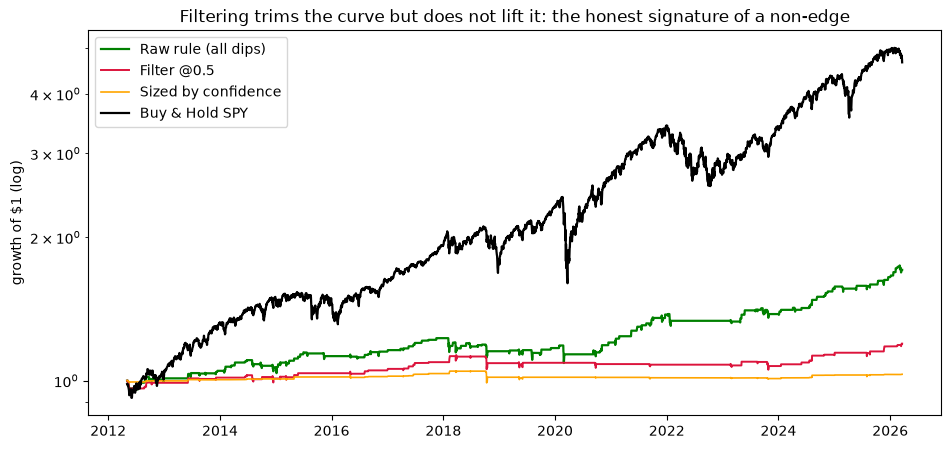

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
styles = {"Raw rule (all dips)": ("green", 1.6), "Filter @0.5": ("crimson", 1.4),
          "Sized by confidence": ("orange", 1.2), "Buy & Hold SPY": ("black", 1.6)}
for name, curve in curves.items():
    c, lw = styles[name]
    ax.plot(curve.index, curve.values, color=c, lw=lw, label=name)
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)")
ax.set_title("Filtering trims the curve but does not lift it: the honest signature of a non-edge")
ax.legend()
plt.show()

## One number is cheap. Show the distribution.

A single AUC or Sharpe is easy to cherry-pick. The honest move on a small sample is to
show the **spread**: how the result wobbles across the walk-forward folds, and across
random seeds of the model. If the edge were real, it would show up *consistently*. If it
is noise, the spread will straddle "nothing."

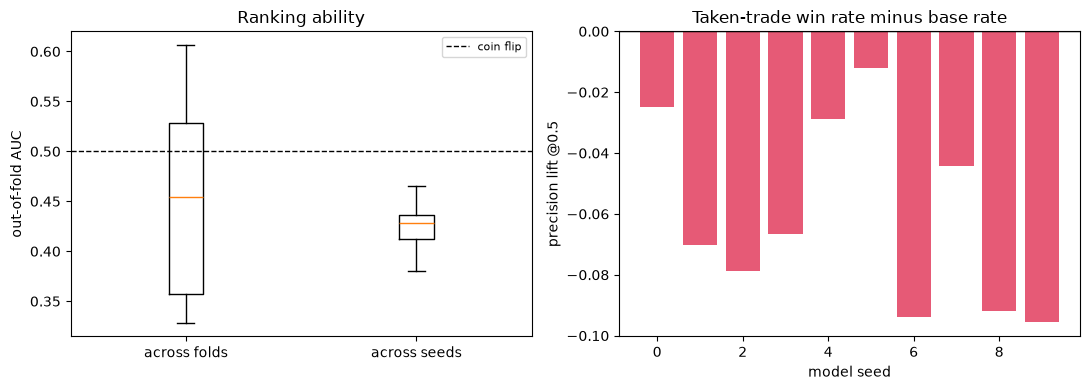

AUC across seeds : 0.38 to 0.47  (every one at or below a coin flip)
precision lift   : -0.095 to -0.012  (negative in every seed)


In [6]:
seed_auc, seed_lift = [], []
for s in range(10):
    pr, _ = out_of_fold_proba(seed=s)
    yt = y.loc[pr.index]
    seed_auc.append(roc_auc_score(yt, pr))
    tk = pr >= 0.5
    seed_lift.append(yt[tk].mean() - yt.mean() if tk.sum() else np.nan)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.boxplot([fold_auc, seed_auc], tick_labels=["across folds", "across seeds"])
a1.axhline(0.5, color="black", ls="--", lw=1, label="coin flip")
a1.set_ylabel("out-of-fold AUC"); a1.set_title("Ranking ability"); a1.legend(fontsize=8)
a2.bar(range(10), seed_lift, color="crimson", alpha=0.7)
a2.axhline(0, color="black", lw=1)
a2.set_xlabel("model seed"); a2.set_ylabel("precision lift @0.5")
a2.set_title("Taken-trade win rate minus base rate")
plt.tight_layout(); plt.show()

print(f"AUC across seeds : {np.min(seed_auc):.2f} to {np.max(seed_auc):.2f}  (every one at or below a coin flip)")
print(f"precision lift   : {np.nanmin(seed_lift):+.3f} to {np.nanmax(seed_lift):+.3f}  (negative in every seed)")

## The honest verdict

**Meta-labeling did not add an edge here, and we can say exactly why.** Across every fold
and every seed, the model's ranking ability sits at or below a coin flip, and its taken
trades win *less* than taking every dip. Filtering bought a smaller drawdown only by
trading less, which is not skill, and it gave up return and Sharpe to do it.

This is not a bug in the pipeline; it is the result the evidence predicted. There was
little to filter (the primary rule is mostly a trend filter with few systematic
mistakes), the underlying reversal edge has decayed, and ~165 trades is simply too few
for a model to learn a faint, noisy pattern. It even echoes the one published
mean-reversion meta-labeling test (Hudson & Thames), whose precision gain **collapsed out
of sample**, from +0.18 in validation to +0.03 live. We measured the right thing, and the
honest answer is *no clear edge*.

A negative result, reached without cheating, is the headline product of this course. The
machinery is now proven trustworthy: triple-barrier labels, overlap-aware weights,
no-look-ahead features, ordered boosting, purged walk-forward, window-matched comparison,
and a distribution instead of a lucky number. It would have happily told us if there were
an edge. There was not.

## What's next

Two threads remain, and both are about resisting the temptation to declare victory:

- **Section 7** swaps the tree for a small **neural network in Apple's MLX**, on the
  identical folds. The honest hypothesis: on a few hundred noisy trades, extra model
  capacity buys little, and a fair "tree vs deep net" comparison should confirm it.
- **Section 9** is the reckoning. By now we have quietly run *many* trials, RSI
  thresholds, barrier multipliers, feature sets, a model, a threshold, a sizer, and each
  one is a chance to get lucky. The **Deflated Sharpe ratio** will charge us for all of
  them and deliver the final, honest answer about whether anything here is real.

The edge, if we are honest, is not in the strategy. It is in the *refusal to fool
ourselves*, and that is the thing worth keeping.